#  **SINIFLANDIRMA**

# K - En Yakın Komşu
- K-Nearest Neighbors (KNN), makine öğrenimi alanında sınıflandırma ve regresyon problemlerini çözmek için kullanılan basit ve popüler bir algoritmadır.
- Temelde, bir veri noktasının sınıfını tahmin etmek veya bir değeri öngörmek için en yakın komşuların etrafındaki veri noktalarının etiketlerini veya değerlerini kullanır.

## KNN Akış Şeması
1. Komşu sayısı K'yı seçin
2. K adet komşunun mesafesini hesaplayın
3. Hesaplanan mesafelere göre K en yakın komşuyu seçin
4. Bu K komşulardan her kategorideki veri noktalarının sayısını sayın
5. Yeni veri noktalarını, komşu sayısı maksimum olan kategoriye atayın.

## Mesafe Nedir?
- Euclidean mesafesi
- Manhattan mesafesi
- Minkowski mesafesi
- Hamming mesafesi

## Hiperparametre Optimizasyonu
- Elbow method, KNN gibi kümeleme veya sınıflandırma algoritmalarında K değerini seçmek için kullanılan bir tekniktir.
- Bu yöntem, farklı K değerlerini deneyerek modelin performansını değerlendirir ve optimum K değerini belirlemeye çalışır.
- Elbow methodu, K değerinin artmasıyla birlikte modelin performansındaki azalışın hızının azalması ve eğrinin dirsek gibi bükülmesi prensibine dayanır.
- Bu dirsek noktası, K değerinin en iyi performansı sağladığı noktayı temsil eder.

### KNN
Amaç:
- Bu çalışma, göğüs kanseri veri setini kullanarak KNN algoritması ile sınıflandırma yapmak.
- Modelin doğruluğunu hesaplayalım, farklı K değerleri için doğruluk analizi yani hiperparametre ayarlaması yapalım.

Veri seti hakkında:
- Veri seti: "Breast Cancer Wisconsin (Diagnostic)" sklearn kütüphanesinin içerisinde bulunur.
- 569 sample, 30 features
- hedef: 2 sınıftan oluşur.
  - 0 -> kötü huylu tümör
  - 1 -> iyi huylu tümör
- features: hücre çekirdeği özellikleri (yarıçap, doku pürüzsüzlüğü, yoğunluk vb.)

Program / akış:
1. Veri setini yükle ve incele
2. Özellik (features) ve hedef (target) değişkenlerin ayrılması
3. Eğitim ve test verilerinin oluşturulması
4. Özniteliklerin ölçeklendirilmesi (standardizasyon)
5. KNN sınıflandırıcının eğitilmesi ve test edilmesi
6. Doğruluk oranı ve confusion matrisin hesaplanması
7. Hiperparametre ayarlaması
8. Sonuçların grafiksel olarak gösterilmesi

In [2]:
# gerekli olan kütüphanelerin içeri aktarılması
from sklearn.datasets import load_breast_cancer # veri seti
from sklearn.neighbors import KNeighborsClassifier # KNN sınıflandırıcısı
from sklearn.metrics import accuracy_score, confusion_matrix # değerlendirme metrikleri
from sklearn.model_selection import train_test_split # veri setini eğitim ve test veri seti olarak 2 ye ayırır.
from sklearn.preprocessing import StandardScaler # ölçeklendirme

import pandas as pd
import matplotlib.pyplot as plt

In [4]:
# 1 - veri seti yükle ve incele
cancer = load_breast_cancer()
df = pd.DataFrame(data = cancer.data, columns = cancer.feature_names)
df['target'] = cancer.target
df.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,radius error,texture error,perimeter error,area error,smoothness error,compactness error,concavity error,concave points error,symmetry error,fractal dimension error,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0


In [5]:
# 2 - feature ve hedef değişkenlerin ayrılması
X = cancer.data
y = cancer.target

In [6]:
# 3 - train test ayrımı
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

In [7]:
# 4 - ölçeklendirme
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [8]:
# 5 - KNN sınıflandırıcı tanımla ve eğit
knn = KNeighborsClassifier(n_neighbors=3) # k=3
knn.fit(X_train, y_train) # eğitim

KNeighborsClassifier(n_neighbors=3)

In [9]:
# 6 - doğruluk ve confusion matris
y_pred = knn.predict(X_test)

In [10]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.9590643274853801

In [12]:
conf_matrix = confusion_matrix(y_test, y_pred)
conf_matrix

array([[ 59,   4],
       [  3, 105]])

In [13]:
# 7 - 8 hyperparameter tuning
accuracy_values = []
k_values = []
for k in range(1,21):
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train, y_train)
  y_pred = knn.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  accuracy_values.append(accuracy)
  k_values.append(k)

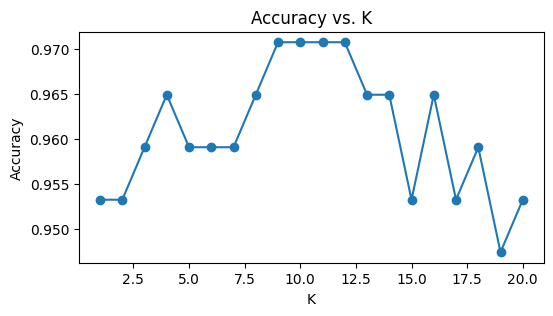

In [17]:
plt.figure(figsize = (6,3))
plt.plot(k_values, accuracy_values, marker='o', linestyle = "-")
plt.title("K değerine karşılık gelen accuracy")
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.title('Accuracy vs. K')
plt.show()